# Cryptocurrency Price Prediction with Regression

This notebook predicts the next day's BTC/USD closing price from daily historical data.

In [1]:
# Run once in VS Code if these packages are not installed.
%pip install pandas matplotlib scikit-learn

You should consider upgrading via the '/Users/hrvineethgowda/web development/AIML project/crypto_price_regression/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Download about 11python3 -m streamlit run app.py years of daily Bitcoin data.
# Skip this cell if btc_usd_daily.csv already exists.
!python3 download_data.py --years 11 --output btc_usd_daily.csv

Downloaded through 2016-06-24 (299 rows)
Downloaded through 2017-04-20 (598 rows)
Downloaded through 2018-02-14 (897 rows)
Downloaded through 2018-12-11 (1196 rows)
Downloaded through 2019-10-07 (1495 rows)
Downloaded through 2020-08-02 (1794 rows)
Downloaded through 2021-05-29 (2093 rows)
Downloaded through 2022-03-25 (2392 rows)
Downloaded through 2023-01-19 (2691 rows)
Downloaded through 2023-11-15 (2990 rows)
Downloaded through 2024-09-10 (3289 rows)
Downloaded through 2025-07-07 (3588 rows)
Downloaded through 2026-05-03 (3887 rows)
Downloaded through 2026-08-27 (4002 rows)
Saved 4002 daily rows to /Users/hrvineethgowda/web development/AIML project/crypto_price_regression/btc_usd_daily.csv


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('btc_usd_daily.csv')
df['date'] = pd.to_datetime(df['date'])
print(f'Dataset rows: {len(df)}')
df.head()

Dataset rows: 4002


,timestamp,date,low,high,open,close,volume
0,1440979200,2015-08-31,225.23,233.00,229.40,230.75,6986.515719
1,1441065600,2015-09-01,226.42,233.50,230.76,228.22,8599.282973
2,1441152000,2015-09-02,226.43,231.43,228.22,229.97,7461.094198
3,1441238400,2015-09-03,226.48,230.79,229.95,227.25,6669.721585
4,1441324800,2015-09-04,227.24,232.49,227.24,231.39,7070.631360


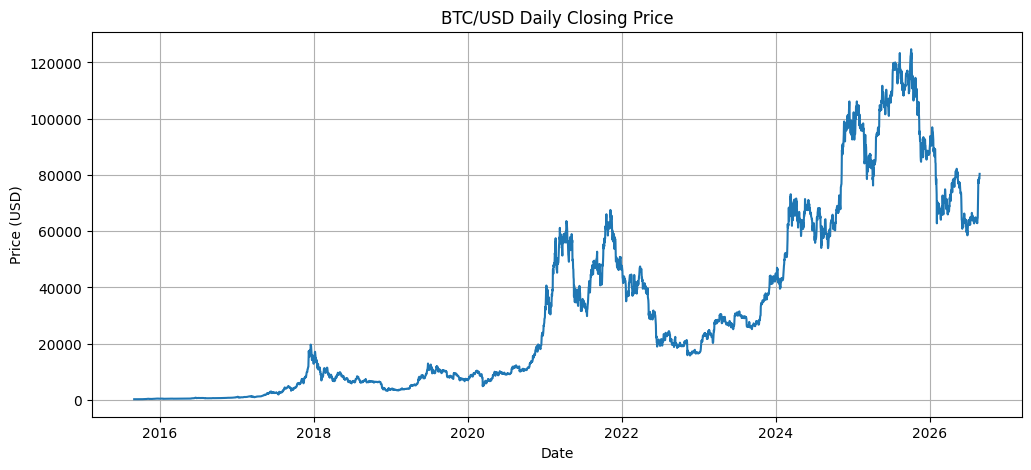

In [4]:
plt.figure(figsize=(12, 5))
plt.plot(df['date'], df['close'])
plt.title('BTC/USD Daily Closing Price')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid()
plt.show()

In [5]:
# Build features using prices known before the next day.
df['lag_1'] = df['close'].shift(1)
df['lag_7'] = df['close'].shift(7)
df['lag_14'] = df['close'].shift(14)
df['ma_7'] = df['close'].rolling(7).mean()
df['target_next_day'] = df['close'].shift(-1)
df = df.dropna().copy()

features = ['close', 'volume', 'lag_1', 'lag_7', 'lag_14', 'ma_7']
X = df[features]
y = df['target_next_day']
split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]
print(f'Training rows: {len(X_train)} | Test rows: {len(X_test)}')

Training rows: 3189 | Test rows: 798


In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def show_metrics(name, actual, predicted):
    print(name)
    print(f'MAE:  ${mean_absolute_error(actual, predicted):,.2f}')
    print(f'RMSE: ${mean_squared_error(actual, predicted) ** 0.5:,.2f}')
    print(f'R2:   {r2_score(actual, predicted):.4f}')

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_predictions = linear_model.predict(X_test)
show_metrics('Linear Regression', y_test, linear_predictions)

rf_model = RandomForestRegressor(n_estimators=300, max_depth=12, min_samples_leaf=2, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
show_metrics('Random Forest', y_test, rf_predictions)

/Users/hrvineethgowda/web development/AIML project/crypto_price_regression/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/hrvineethgowda/web development/AIML project/crypto_price_regression/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/hrvineethgowda/web development/AIML project/crypto_price_regression/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


Linear Regression
MAE:  $1,421.40
RMSE: $1,987.14
R2:   0.9892
Random Forest
MAE:  $19,449.07
RMSE: $25,906.65
R2:   -0.8365


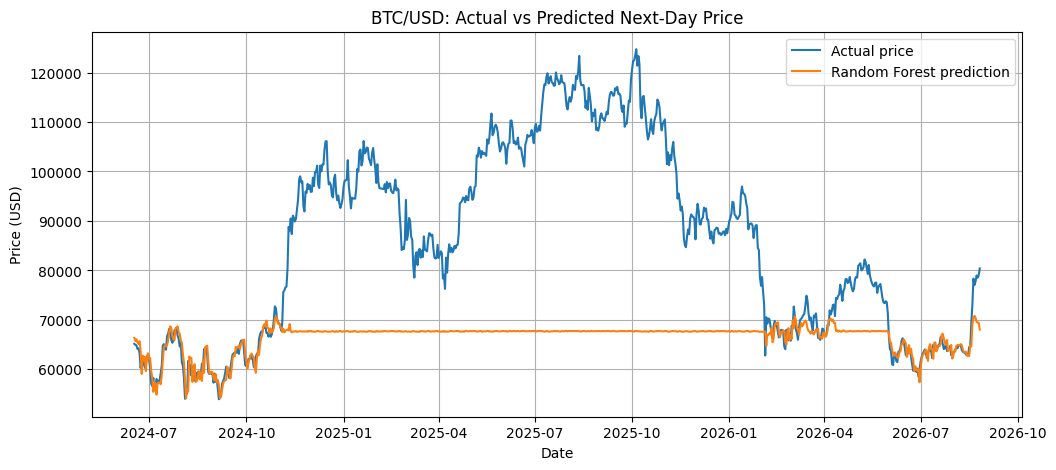

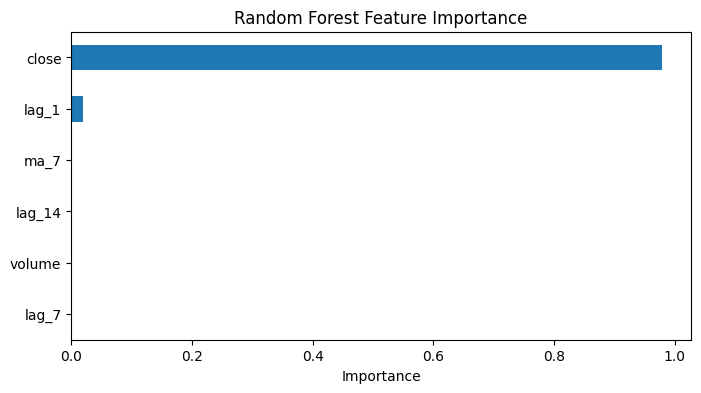

In [7]:
test_dates = df['date'].iloc[split:]
plt.figure(figsize=(12, 5))
plt.plot(test_dates, y_test, label='Actual price')
plt.plot(test_dates, rf_predictions, label='Random Forest prediction')
plt.title('BTC/USD: Actual vs Predicted Next-Day Price')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid()
plt.show()

pd.Series(rf_model.feature_importances_, index=features).sort_values().plot(
    kind='barh', figsize=(8, 4), title='Random Forest Feature Importance'
)
plt.xlabel('Importance')
plt.show()